<a href="https://colab.research.google.com/github/Jashan-jj/RFM-model-based-customer-segmentation/blob/jashan/notebook/Customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df= pd.read_excel('dataset/Online Retail.xlsx')

# 1. Data Understanding

# Approaches to Handle thing large Dataset:
1. Go with this large dataset or you implement step 2 on this dataset after EDA and Feature Engineering.
2. make a new dataset out of this dataset, converting multiple transactions (happened at same time) based on CustomerID, and sum the Quantity, unitPrice and TotalValue. Then the dataset size will be reduced from 4 lakhs rows to only 4000+ rows.

In [ ]:
df

In [30]:
df1= df.copy()

In [31]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


# 2. Data Cleaning and Preparation
Handling Missing Values

In [32]:
df1.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [33]:
df1.loc[df['Description'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


In [34]:
df1.loc[np.where(df1['Description'].isnull() & df1['CustomerID'].isnull())]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


Description has 1454 null values and CustomerID has 135080 null values (Alot)

All NULL instances in the Description has UnitPrice Zero

All the Description that has null values, there CustomerID also has null value

There might be some system error, better to drop these rows

In [35]:
idx= df.loc[df['Description'].isnull()].index
print(idx.size)
df2= df1.drop(idx, axis=0)

1454


CustomerID has 135080 Null Values: there are two ways to resolve this

- remove all those rows
- check for the pervious or next trancation's InvoiceDate; if it is same then raplce the null value with the transaction's CustomerID values. if its no possible then fill Unknown.

all null values will be removed

In [36]:
df['CustomerID'].unique().size

4373

In [37]:
df2[df2['CustomerID'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom


In [38]:
df2= df2.dropna(subset=['CustomerID'], axis=0)

In [39]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


Data Analysis: InvoiceNO has two type of trasaction,

InvoiceNO value starting with 'c' indicates return or cancelled

In [40]:
df2['InvoiceNo'].nunique()

22190

i observe that there are 8905 rows where customers has cancelled or returned their product, now i will remove these rows it will not help in customer purchase analysis

In [41]:
idx= df2[df2['InvoiceNo'].astype(str).str.startswith('C')].index
print(idx.size)
df3= df2.drop(idx, axis=0)

8905


In [42]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


In [43]:
df3.groupby('CustomerID')['InvoiceNo'].nunique()

,InvoiceNo
CustomerID,
12346.0,1
12347.0,7
12348.0,4
12349.0,1
12350.0,1
...,...
18280.0,1
18281.0,1
18282.0,2


In [44]:
df3['TotalValue']= df3['Quantity'] * df['UnitPrice']

In [45]:
df3

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalValue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [46]:
df3[df3.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalValue
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2.10
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,2.95
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom,2.95
...,...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom,0.39
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom,2.49
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom,1.95
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom,2.10


In [47]:
df3.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalValue
count,397924.000000,397924,397924.000000,397924.000000,397924.000000
mean,13.021823,2011-07-10 23:43:36.912475648,3.116174,15294.315171,22.394749
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.420210,NaN,22.096788,1713.169877,309.055588


There are 360 rows that has UnitPrice Value 0; better to remove these as well

In [48]:
idx= df3[df3['UnitPrice']==0].index
df4= df3.drop(idx, axis=0)

Data Formatting

In [49]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalValue   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [50]:
df4

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalValue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [51]:
df5= df4.astype({'InvoiceNo': int, 'Quantity': int, 'CustomerID': int})

In [52]:
df5['InvoiceDate']= pd.to_datetime(df5['InvoiceDate'])

In [53]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  int64         
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
 8   TotalValue   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 30.4+ MB


# Outilers Handling

Quantity column has significant large outlier values which directly affects the TotalValue Column

decision:

Taking only rows that are close and under the IQR of Quantity Column (Dataset reduced by 54628 rows)

In [54]:
df5.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalValue
count,397884.000000,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,560616.934451,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,549234.000000,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,561893.000000,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,572090.000000,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,581587.000000,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,13106.117773,179.331775,NaN,22.097877,1713.141560,309.071041


In [55]:
idx= df5[(df5['Quantity'] >20)].index
print(idx.size)
df6= df5.drop(idx, axis=0)

54628


<Axes: xlabel='Quantity', ylabel='Count'>

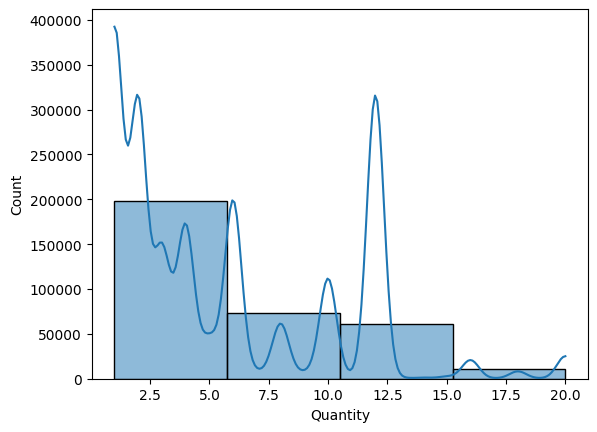

In [56]:
sns.histplot(df6['Quantity'], kde= True, binwidth=5)

In [57]:
df6.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalValue
count,343256.000000,343256.000000,343256,343256.000000,343256.000000,343256.000000
mean,560694.479313,5.583040,2011-07-11 12:51:29.207996160,3.412653,15335.317696,13.455103
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,12347.000000,0.001000
25%,549235.000000,2.000000,2011-04-07 11:16:00,1.250000,14032.000000,3.900000
50%,561925.500000,4.000000,2011-08-01 12:38:00,2.080000,15252.000000,10.200000
75%,572287.000000,10.000000,2011-10-23 12:26:00,3.750000,16839.000000,17.400000
max,581587.000000,20.000000,2011-12-09 12:50:00,8142.750000,18287.000000,8142.750000
std,13161.413130,4.606046,NaN,23.746169,1707.168117,27.853324


UnitPrice Also has outliers that are affecting the totalValue Column

descision:
Drop those rows with UnitPrice > 10

<Axes: ylabel='UnitPrice'>

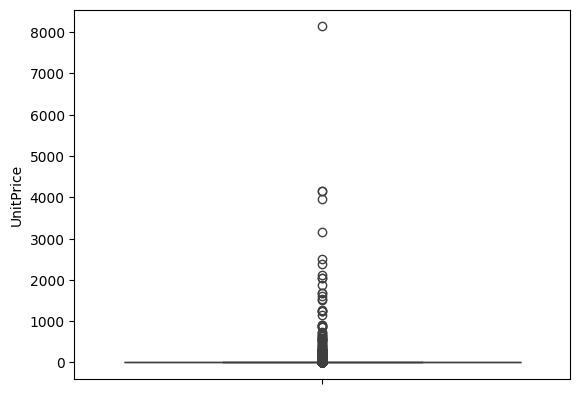

In [58]:
sns.boxplot(df6['UnitPrice'])

In [59]:
idx= df6[df6['UnitPrice'] > 10].index
print(idx.size)
df7= df6.drop(idx, axis=0)

10679


<Axes: ylabel='UnitPrice'>

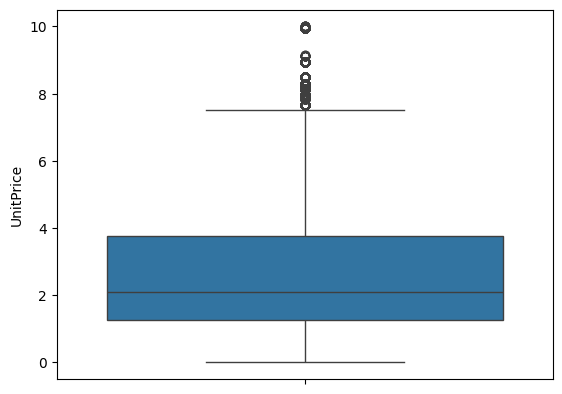

In [60]:
sns.boxplot(df7['UnitPrice'])

In [61]:
df7.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalValue
count,332577.000000,332577.000000,332577,332577.000000,332577.000000,332577.000000
mean,560727.801279,5.679867,2011-07-11 19:32:44.379977984,2.745362,15350.456021,12.374791
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,12347.000000,0.001000
25%,549245.000000,2.000000,2011-04-07 11:59:00,1.250000,14048.000000,3.750000
50%,562031.000000,4.000000,2011-08-01 17:37:00,2.080000,15296.000000,9.950000
75%,572295.000000,10.000000,2011-10-23 13:49:00,3.750000,16871.000000,17.000000
max,581587.000000,20.000000,2011-12-09 12:50:00,10.000000,18287.000000,199.000000
std,13165.169558,4.618117,NaN,2.203642,1703.806717,12.194086


# 3. Exploratory Data Analysis

In [62]:
df7.shape

(332577, 9)

<Axes: xlabel='TotalValue', ylabel='Count'>

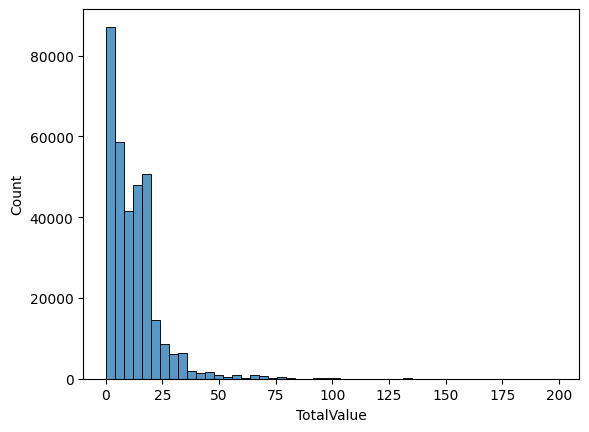

In [63]:
sns.histplot(df7['TotalValue'], bins=50)

<Axes: xlabel='Description'>

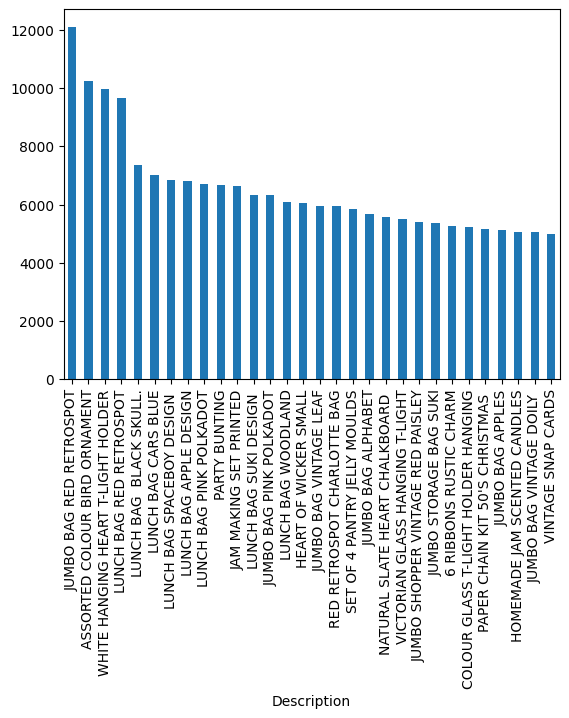

In [64]:
top_products= df7.groupby('Description')['Quantity'].sum().sort_values(ascending= False).head(30)
top_products.plot(kind= 'bar')

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

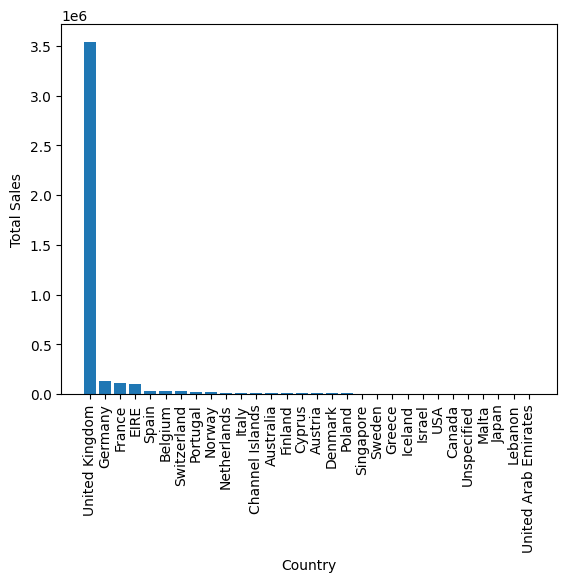

In [65]:
country_sales= df7.groupby('Country')['TotalValue'].sum().sort_values(ascending= False).head(30)
plt.bar(country_sales.index, country_sales.values)
plt.xticks(rotation= 90)
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt

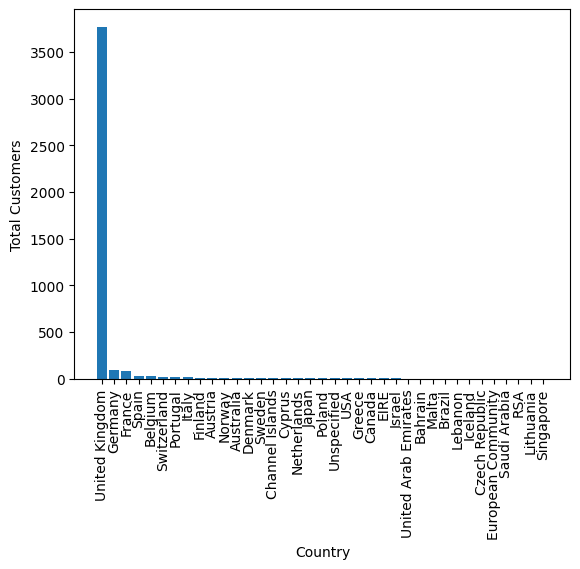

In [66]:
country= df7.groupby('Country')['CustomerID'].nunique().sort_values(ascending= False)
plt.bar(country.index, country.values)
plt.xticks(rotation= 90)
plt.xlabel('Country')
plt.ylabel('Total Customers')
plt.show()

from this visualization we can directly see that most of the customers are from UK and now we do two types of customer segmentations;

1. do the customer clustering of the whole dataset
2. do the customer clusering in United Kingdom only

/tmp/ipykernel_330/4062320101.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ttlval_months= df7.set_index('InvoiceDate').resample('M')["TotalValue"].sum()


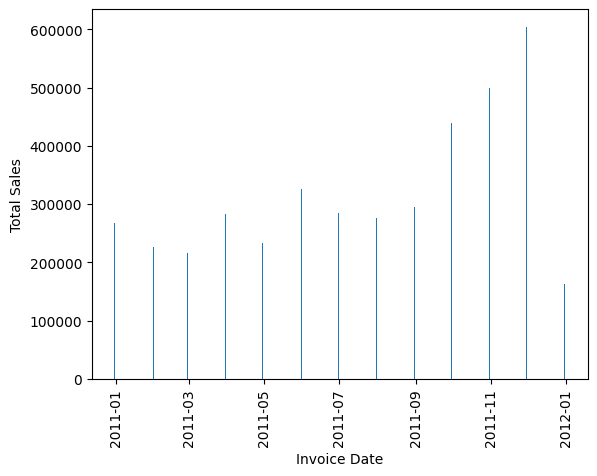

In [67]:
ttlval_months= df7.set_index('InvoiceDate').resample('M')["TotalValue"].sum()
plt.bar(ttlval_months.index, ttlval_months.values, width= 0.8)
plt.xticks(rotation= 90)
plt.xlabel('Invoice Date')
plt.ylabel('Total Sales')
plt.show()

(array([3.163e+03, 6.100e+02, 1.970e+02, 8.400e+01, 4.600e+01, 2.400e+01,
        1.500e+01, 1.200e+01, 5.000e+00, 8.000e+00, 1.000e+00, 2.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 2.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00]),
 array([  1.  ,   4.84,   8.68,  12.52,  16.36,  20.2 ,  24.04,  27.88,
         31.72,  35.56,  39.4 ,  43.24,  47.08,  50.92,  54.76,  58.6 ,
         62.44,  66.28,  70.12,  73.96,  77.8 ,  81.64,  85.48,  89.32,
         93.16,  97.  , 100.84, 104.68, 108.52, 112.36, 116.2 , 120.04,
        123.88, 127.72, 131.56, 135.4 , 139.24, 143.08, 146.92, 150.76,
        154.6 , 

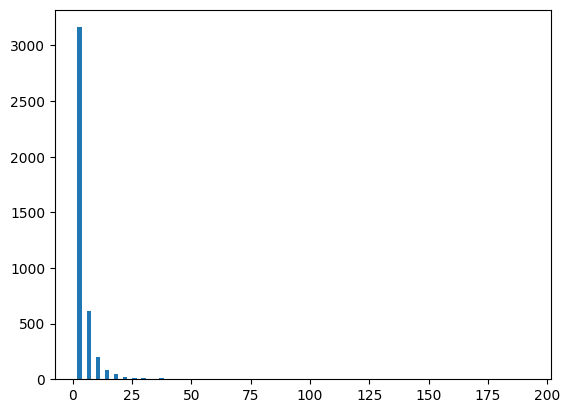

In [68]:
purchase_freq= df7.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False)
plt.hist(purchase_freq, bins= 50, rwidth= 0.5)

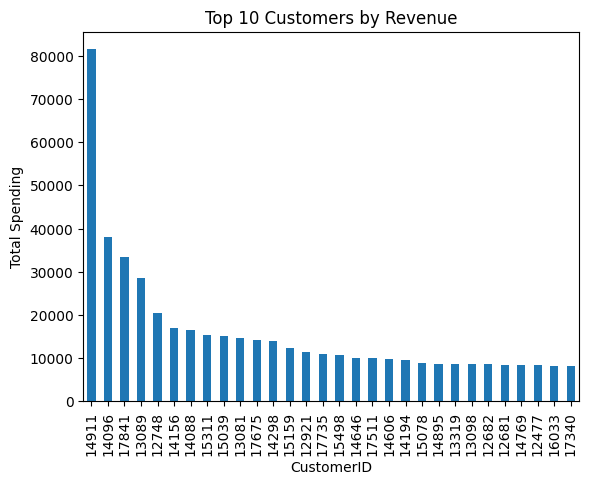

In [69]:
top_customers = df7.groupby("CustomerID")["TotalValue"].sum().sort_values(ascending=False).head(30)
plt.figure()
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Revenue")
plt.ylabel("Total Spending")
plt.show()

In [70]:
df7.info()

<class 'pandas.core.frame.DataFrame'>
Index: 332577 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    332577 non-null  int64         
 1   StockCode    332577 non-null  object        
 2   Description  332577 non-null  object        
 3   Quantity     332577 non-null  int64         
 4   InvoiceDate  332577 non-null  datetime64[ns]
 5   UnitPrice    332577 non-null  float64       
 6   CustomerID   332577 non-null  int64         
 7   Country      332577 non-null  object        
 8   TotalValue   332577 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 25.4+ MB


important columns:
Quantity, UnitPrice, InvoiceDate (To Calculate Recency and Frequency), TotalValue

# Feature Enginnering

new features we can make:

Recency: Last_date - Last_purchase_date

Frequency: how often customers buys

Monetary = Total spending

Average ordering Value (bulk buyers or small buyers): TotalValue / Number of Orders



In [71]:
reference_date= df7['InvoiceDate'].max() + pd.DateOffset(days=1)
last_purchase= df7.groupby('CustomerID')['InvoiceDate'].max()
recency= (reference_date - last_purchase).dt.days

In [72]:
df8= df7.copy()
df8['Recency']= df8['CustomerID'].map(recency)

In [73]:
rfm_df= recency.reset_index()
rfm_df.columns= ['CustomerID', 'Recency']

In [74]:
rfm_df.Recency.sum()

np.int64(388938)

In [75]:
df8[(df8['Recency'] <50) & (df8['InvoiceDate'] < '2011-2-01 08:26:00')].groupby('CustomerID').head(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalValue,Recency
10,536367,22745,POPPY'S PLAYHOUSE BEDROOM,6,2010-12-01 08:34:00,2.10,13047,United Kingdom,12.60,32
11,536367,22748,POPPY'S PLAYHOUSE KITCHEN,6,2010-12-01 08:34:00,2.10,13047,United Kingdom,12.60,32
12,536367,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,8,2010-12-01 08:34:00,3.75,13047,United Kingdom,30.00,32
13,536367,22310,IVORY KNITTED MUG COSY,6,2010-12-01 08:34:00,1.65,13047,United Kingdom,9.90,32
14,536367,84969,BOX OF 6 ASSORTED COLOUR TEASPOONS,6,2010-12-01 08:34:00,4.25,13047,United Kingdom,25.50,32
...,...,...,...,...,...,...,...,...,...,...
77635,542776,79321,CHILLI LIGHTS,4,2011-02-01 08:23:00,4.95,15240,United Kingdom,19.80,45
77637,542776,22835,HOT WATER BOTTLE I AM SO POORLY,4,2011-02-01 08:23:00,4.65,15240,United Kingdom,18.60,45
77638,542776,22083,PAPER CHAIN KIT RETROSPOT,12,2011-02-01 08:23:00,2.95,15240,United Kingdom,35.40,45
77640,542776,21218,RED SPOTTY BISCUIT TIN,6,2011-02-01 08:23:00,3.75,15240,United Kingdom,22.50,45


In [76]:
df8.info()

<class 'pandas.core.frame.DataFrame'>
Index: 332577 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    332577 non-null  int64         
 1   StockCode    332577 non-null  object        
 2   Description  332577 non-null  object        
 3   Quantity     332577 non-null  int64         
 4   InvoiceDate  332577 non-null  datetime64[ns]
 5   UnitPrice    332577 non-null  float64       
 6   CustomerID   332577 non-null  int64         
 7   Country      332577 non-null  object        
 8   TotalValue   332577 non-null  float64       
 9   Recency      332577 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 27.9+ MB


Frequency

In [77]:
frequency = df8.groupby("CustomerID")["InvoiceNo"].nunique()
df8['Frequency']= df8['CustomerID'].map(frequency)

In [78]:
rfm_df['Frequency']= rfm_df['CustomerID'].map(frequency)

In [79]:
rfm_df['Frequency'].sum()

np.int64(16633)

In [80]:
df8.info()

<class 'pandas.core.frame.DataFrame'>
Index: 332577 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    332577 non-null  int64         
 1   StockCode    332577 non-null  object        
 2   Description  332577 non-null  object        
 3   Quantity     332577 non-null  int64         
 4   InvoiceDate  332577 non-null  datetime64[ns]
 5   UnitPrice    332577 non-null  float64       
 6   CustomerID   332577 non-null  int64         
 7   Country      332577 non-null  object        
 8   TotalValue   332577 non-null  float64       
 9   Recency      332577 non-null  int64         
 10  Frequency    332577 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(5), object(3)
memory usage: 30.4+ MB


Monetary

In [81]:
monetary = df8.groupby('CustomerID')['TotalValue'].sum()
df8['Monetary']= df8['CustomerID'].map(monetary)
rfm_df['Monetary']= rfm_df['CustomerID'].map(monetary)

In [82]:
df8.info()

<class 'pandas.core.frame.DataFrame'>
Index: 332577 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    332577 non-null  int64         
 1   StockCode    332577 non-null  object        
 2   Description  332577 non-null  object        
 3   Quantity     332577 non-null  int64         
 4   InvoiceDate  332577 non-null  datetime64[ns]
 5   UnitPrice    332577 non-null  float64       
 6   CustomerID   332577 non-null  int64         
 7   Country      332577 non-null  object        
 8   TotalValue   332577 non-null  float64       
 9   Recency      332577 non-null  int64         
 10  Frequency    332577 non-null  int64         
 11  Monetary     332577 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(5), object(3)
memory usage: 33.0+ MB


# Customer-Level Dataset

In [83]:
customer_df = df8.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (df8["InvoiceDate"].max() + pd.Timedelta(days=1) - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalValue": "sum",
    "Quantity": "sum",
    "StockCode": "nunique"
})

In [84]:
customer_df.columns = ["Recency", "Frequency", "Monetary", "TotalQuantity", "UniqueProducts"]
customer_df = customer_df.reset_index()
customer_df

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts
0,12347,2,7,2906.57,1285,89
1,12348,249,1,17.00,20,1
2,12349,19,1,1175.65,475,62
3,12350,310,1,274.00,172,15
4,12352,36,7,1321.99,521,56
...,...,...,...,...,...,...
4170,18280,278,1,180.60,45,10
4171,18281,181,1,46.92,52,5
4172,18282,8,2,113.13,51,8
4173,18283,4,16,2078.93,1396,262


In [85]:
customer_df.describe()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts
count,4175.00000,4175.000000,4175.000000,4175.000000,4175.000000,4175.000000
mean,15292.82012,93.158802,3.983952,985.765493,452.453413,54.583952
std,1719.48713,100.196919,6.947505,2083.466723,920.785440,76.872489
min,12347.00000,1.000000,1.000000,1.900000,1.000000,1.000000
25%,13810.50000,18.000000,1.000000,202.890000,88.500000,13.000000
50%,15287.00000,51.000000,2.000000,458.250000,215.000000,31.000000
75%,16773.50000,146.000000,4.000000,1086.205000,510.000000,68.000000
max,18287.00000,374.000000,193.000000,81464.080000,34920.000000,1643.000000


# 4. Customer Behaviour Analysis

In [86]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [87]:
X= customer_df.drop(['CustomerID'], axis=1)

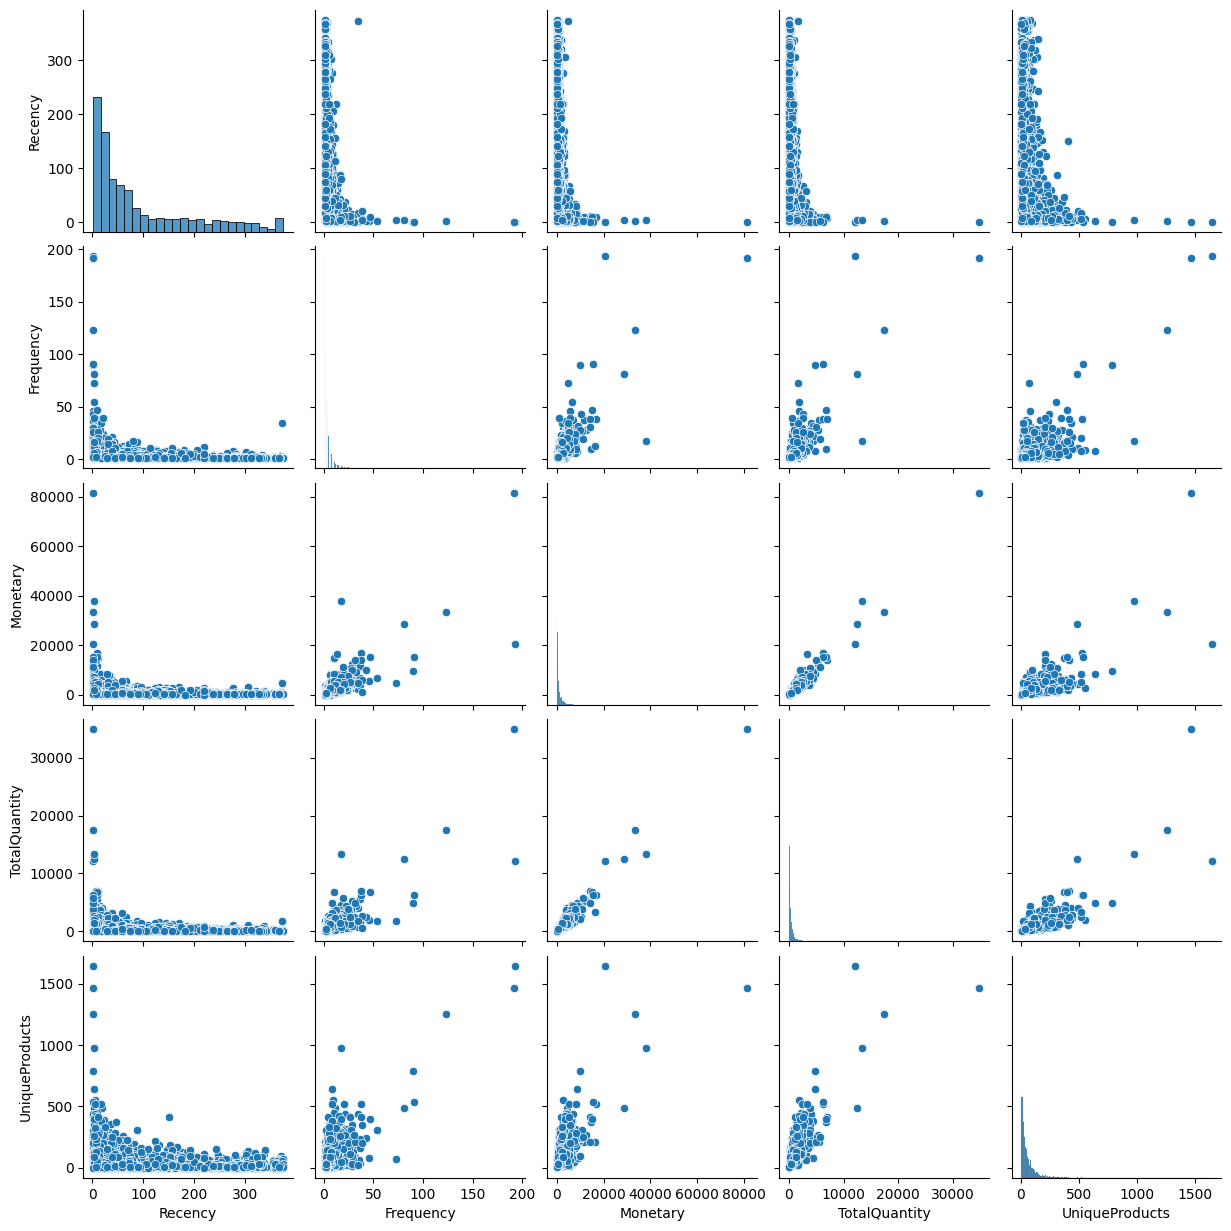

In [88]:
sns.pairplot(X)

Most of the Data is Left Skewed, Close to 0.
Can perform log transformation to balance it

In [89]:
x_log= np.log1p(X)

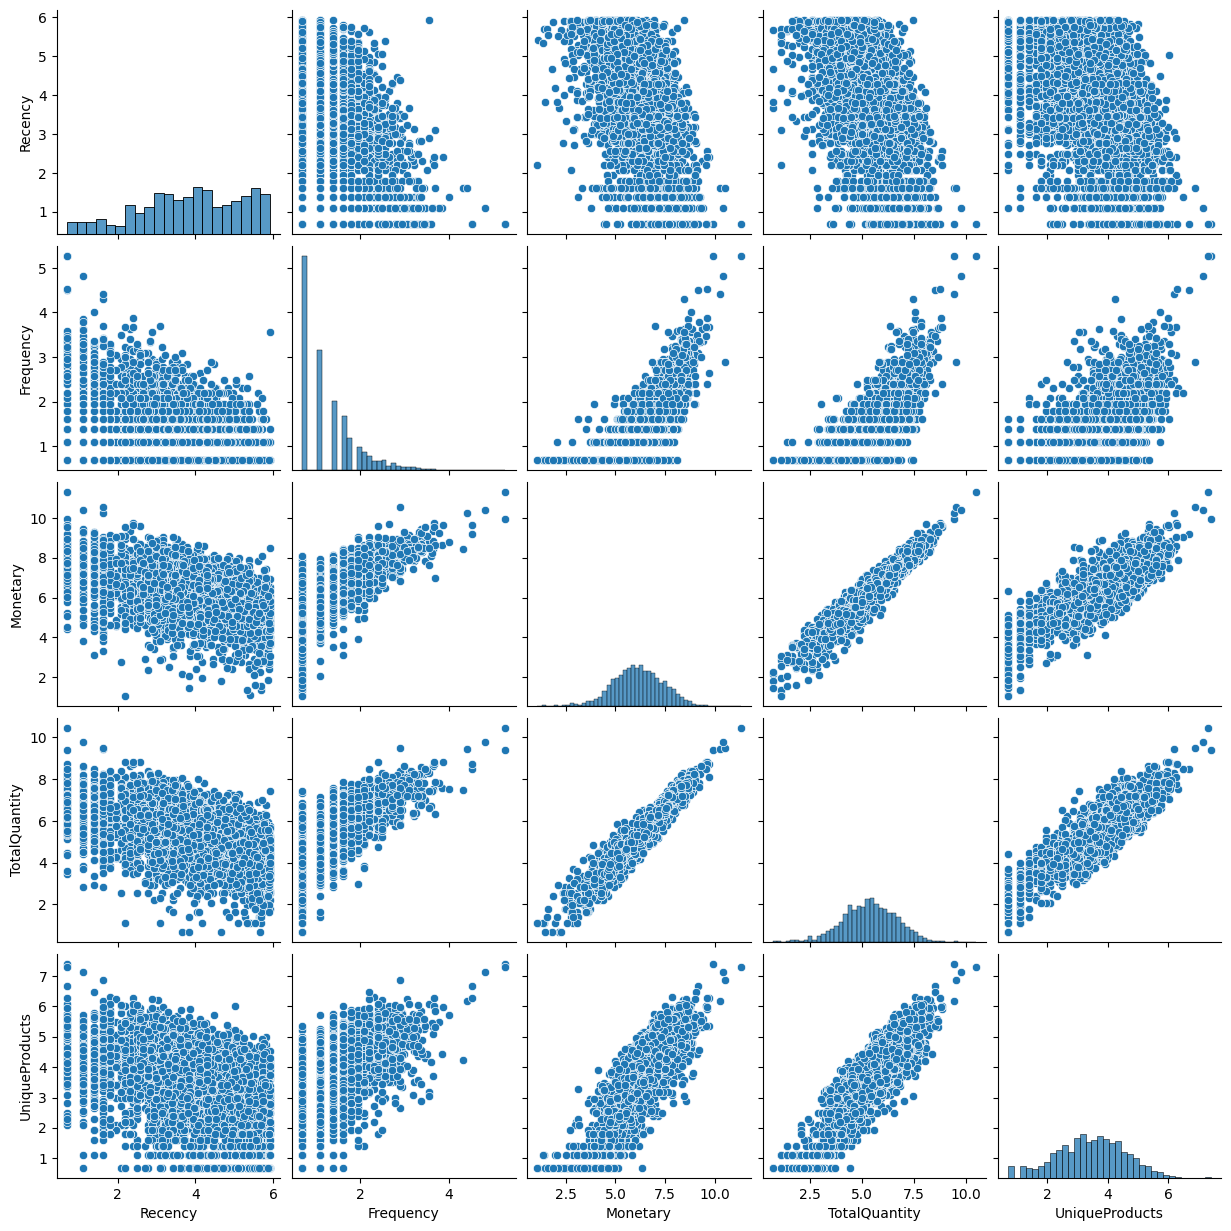

In [90]:
sns.pairplot(x_log)

In [91]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_scaled= scaler.fit_transform(x_log)

PCA

In [92]:
from sklearn.decomposition import PCA
pca= PCA()
pca.fit(x_scaled)

PCA()

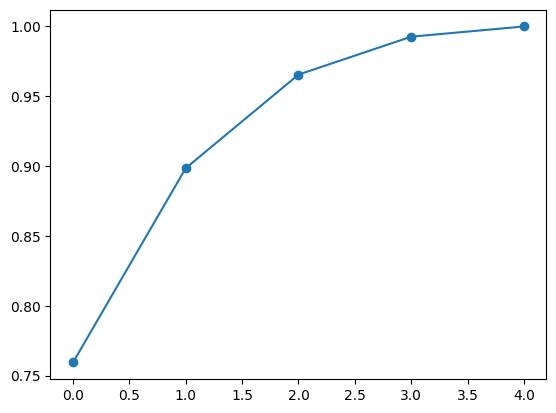

In [93]:
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker= 'o')

In [94]:
pca= PCA(n_components=3)
xpca= pca.fit_transform(x_scaled)
xpca

array([[ 3.05901083, -1.03980754, -0.29055973],
       [-4.11783628, -0.49645849,  0.86397524],
       [ 0.76693802,  0.11393229, -1.32304409],
       ...,
       [-1.32464183, -1.87459614, -0.10310372],
       [ 3.77264238, -0.64595339,  0.32664563],
       [ 0.13518136,  0.39043981, -0.28749153]])

In [95]:
xpca= pd.DataFrame(xpca, columns= ['PC1', 'PC2', 'PC3'])
xpca

,PC1,PC2,PC3
0,3.059011,-1.039808,-0.290560
1,-4.117836,-0.496458,0.863975
2,0.766938,0.113932,-1.323044
3,-1.440351,1.096339,-0.031399
4,1.585327,0.180484,0.586022
...,...,...,...
4170,-2.241072,0.603727,0.202815
4171,-2.849130,-0.057869,0.286335
4172,-1.324642,-1.874596,-0.103104
4173,3.772642,-0.645953,0.326646


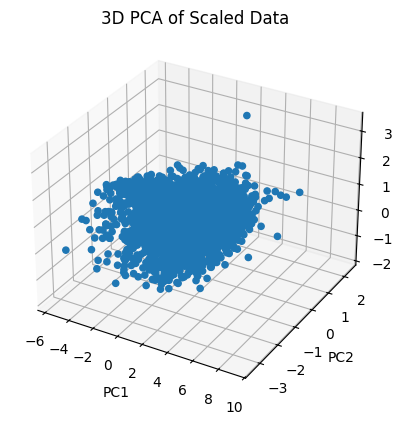

In [96]:
plt.figure()
ax = plt.axes(projection= '3d')
ax.scatter(xpca['PC1'], xpca['PC2'], xpca['PC3'], alpha=1)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('3D PCA of Scaled Data')
plt.show()

KMeans Clustering

<Axes: >

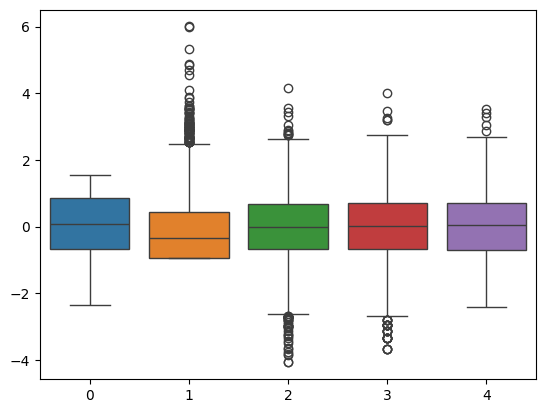

In [97]:
sns.boxplot(x_scaled)

In [98]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
wcss= []
ss= []

for i in range(2,11):
  kmeans= KMeans(n_clusters= i, init= 'k-means++', random_state= 42)
  kmeans.fit(x_scaled)
  clusters= kmeans.predict(x_scaled)
  wcss.append(kmeans.inertia_)
  ss.append(silhouette_score(x_scaled, clusters, metric= 'euclidean'))

ss

[np.float64(0.4109988517306471),
 np.float64(0.3100989860014805),
 np.float64(0.262488577551587),
 np.float64(0.26885294009502647),
 np.float64(0.25187267587734596),
 np.float64(0.2381519921100633),
 np.float64(0.24122629562597991),
 np.float64(0.23067915249506715),
 np.float64(0.2222203993664575)]

Text(0, 0.5, 'WCSS')

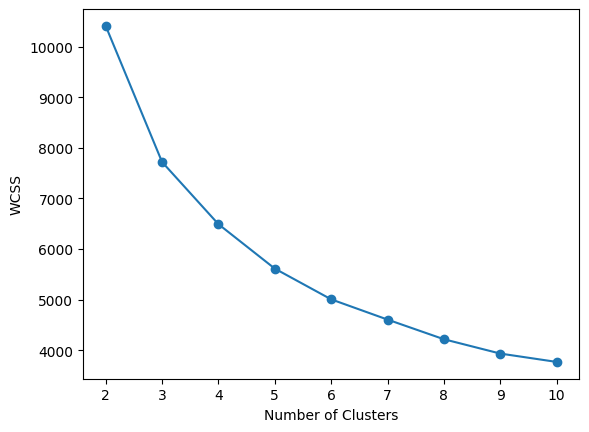

In [99]:
plt.plot(range(2,11), wcss, marker= 'o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

Text(0, 0.5, 'Silhouette Score')

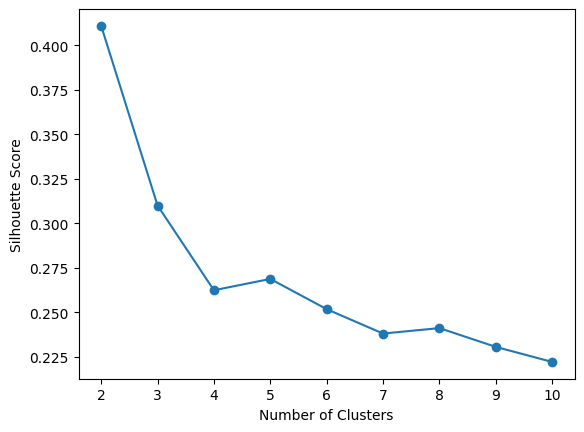

In [100]:
plt.plot(range(2,11), ss, marker= 'o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

n_clusters= 4

In [101]:
kmeans= KMeans(n_clusters= 4, init= 'k-means++', random_state= 42)
clusters= kmeans.fit_predict(x_scaled)

In [102]:
print(silhouette_score(x_scaled,clusters))
print(calinski_harabasz_score(x_scaled,clusters))
print(davies_bouldin_score(x_scaled,clusters))

0.262488577551587
3081.9593366190747
1.1643273044265112


In [103]:
customer_df['Clusters']= clusters

In [104]:
customer_df['Clusters'].value_counts()

,count
Clusters,
3,1446
0,1279
2,804
1,646


In [105]:
customer_df.groupby("Clusters").mean().T

Clusters,0,1,2,3
CustomerID,15246.304926,15229.526316,15394.674129,15305.607192
Recency,44.129007,16.116099,155.296020,136.395574
Frequency,3.845192,12.846749,1.267413,1.657676
Monetary,973.108399,3535.545372,104.375983,347.914725
TotalQuantity,455.749805,1611.167183,42.777363,159.669433
UniqueProducts,65.030493,157.252322,6.483831,26.221300


 1: VIP Customers
      
 0: Regular Customers

 3: At-Risk Customers

 2: Lost Customers     


Hierarical Clustring

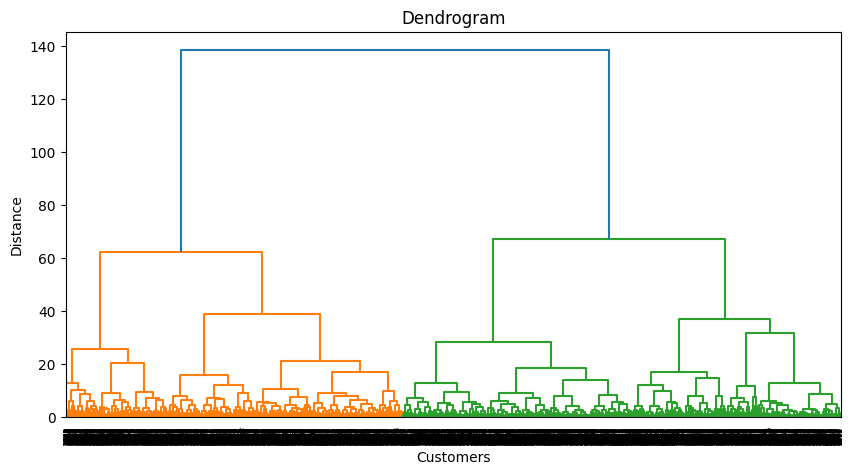

In [106]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(x_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [107]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4)
customer_df["HC_Cluster"] = hc.fit_predict(x_scaled)

In [108]:
customer_df.groupby("HC_Cluster").mean()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,Clusters
HC_Cluster,,,,,,,
0,15355.699842,34.040284,4.369668,1019.922355,471.359400,67.910742,0.436809
1,15396.296693,143.339589,1.302949,133.573485,57.141197,9.878463,2.256479
2,15173.761712,145.001616,1.908724,492.577111,224.450727,32.261712,2.419225
3,15205.860507,10.750000,13.188406,3741.068913,1721.813406,164.708333,0.940217


In [109]:
customer_df["HC_Cluster"].value_counts()

,count
HC_Cluster,
0,1266
2,1238
1,1119
3,552


DBSCAN

In [110]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
customer_df["DBSCAN_Cluster"] = dbscan.fit_predict(x_scaled)

In [111]:
customer_df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,2448
1,1415
-1,307
2,5


In [112]:
customer_df.groupby("DBSCAN_Cluster").mean()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,Clusters,HC_Cluster
DBSCAN_Cluster,,,,,,,,
-1,15443.270358,59.195440,11.319218,2571.411433,1087.768730,101.879479,1.293160,1.221498
0,15283.392565,59.639297,4.794935,1227.142889,572.852124,69.457108,1.076797,1.214869
1,15270.219081,158.832509,1.000000,226.915103,107.330742,18.585159,2.513074,1.344170
2,17067.000000,4.000000,1.000000,203.392000,166.600000,56.400000,0.600000,0.000000


Clustering on PCA

In [113]:
# import plotly.express as px

# # Add the cluster information to the PCA DataFrame for coloring
# xpca_with_clusters = xpca.copy()
# xpca_with_clusters['Cluster'] = customer_df['HC_Cluster']

# # Create the interactive 3D scatter plot
# fig = px.scatter_3d(
#     xpca_with_clusters,
#     x='PC1',
#     y='PC2',
#     z='PC3',
#     color='Cluster', # Color points by cluster
#     symbol='Cluster', # Use different symbols for each cluster
#     title='Interactive 3D PCA of Scaled Data with Clusters',
#     labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2', 'PC3': 'Principal Component 3'},
#     width=800,
#     height=600,
#     opacity=0.5
# )

# # Display the plot
# fig.show()



In [114]:
customer_df.drop(['HC_Cluster',	'DBSCAN_Cluster'], axis=1, inplace=True)

In [115]:
cluster_labels = {
    0: "Regular Customers",
    1: "VIP Customers",
    2: "Lost Customers",
    3: "At-Risk Customers"
}

customer_df["Customer_Segment"] = customer_df["Clusters"].map(cluster_labels)

customer_df.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,Clusters,Customer_Segment
0,12347,2,7,2906.57,1285,89,1,VIP Customers
1,12348,249,1,17.00,20,1,2,Lost Customers
2,12349,19,1,1175.65,475,62,0,Regular Customers
3,12350,310,1,274.00,172,15,3,At-Risk Customers
4,12352,36,7,1321.99,521,56,0,Regular Customers


# Model Training

In [116]:
X= customer_df.drop(['CustomerID', 'Clusters', 'Customer_Segment'], axis=1)
y= customer_df['Clusters']

In [117]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [118]:
x_train.shape, y_train.shape

((3340, 5), (3340,))

In [119]:
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd

def find_best_model_using_gridsearchcv(X, y):

    algos = {

        'logistic_regression': {
            'model': LogisticRegression(max_iter=1000),
            'params': {
                'C': [0.1, 1, 10]
            }
        },

        'knn': {
            'model': KNeighborsClassifier(),
            'params': {
                'n_neighbors': [3,5,7,9,11]
            }
        },

        'decision_tree': {
            'model': DecisionTreeClassifier(),
            'params': {
                'criterion': ['gini', 'entropy'],
                'max_depth': [5, 10, 20]
            }
        },

        'random_forest': {
            'model': RandomForestClassifier(random_state=42),
            'params': {
                'n_estimators': [100, 200],
                'max_depth': [None, 10, 20]
            }
        },

        'xgboost': {
            'model': XGBClassifier(eval_metric="mlogloss", random_state=42),
            'params': {
                'n_estimators': [50, 100],
                'max_depth': [3, 5, 7],
                'learning_rate': [0.01, 0.1]
            }
        }
    }

    scores = []

    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

    for algo_name, config in algos.items():
        gs = GridSearchCV(
            config['model'],
            config['params'],
            cv=cv,
            scoring='accuracy',
            return_train_score=False,
            n_jobs=-1
        )

        gs.fit(X, y)

        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })

    return pd.DataFrame(scores, columns=['model','best_score','best_params'])

In [120]:
model_scores= find_best_model_using_gridsearchcv(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [121]:
model_scores

,model,best_score,best_params
0,logistic_regression,0.864431,{'C': 1}
1,knn,0.869461,{'n_neighbors': 5}
2,decision_tree,0.933653,"{'criterion': 'entropy', 'max_depth': 20}"
3,random_forest,0.961437,"{'max_depth': 20, 'n_estimators': 200}"
4,xgboost,0.964311,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."


In [122]:
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix)

In [123]:
xgb= XGBClassifier(learning_rate= 0.1, max_depth= 3, n_estimators= 100)
xgb.fit(x_train, y_train)
y_pred= xgb.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9544910179640719
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       252
           1       0.99      0.94      0.96       141
           2       0.97      0.99      0.98       139
           3       0.95      0.96      0.95       303

    accuracy                           0.95       835
   macro avg       0.96      0.96      0.96       835
weighted avg       0.95      0.95      0.95       835



In [124]:
print(confusion_matrix(y_test, y_pred))

[[236   2   0  14]
 [  8 133   0   0]
 [  0   0 138   1]
 [  8   0   5 290]]


In [125]:
y_prob= xgb.predict_proba(x_test)

In [126]:
print(roc_auc_score(y_test, y_prob, multi_class='ovr', labels=xgb.classes_))

0.9977582935817003
